# SoH barrel count vs Kayrros inventories

Consistency check: **are we under/over-counting crude leaving the Strait of Hormuz?**

Uses three series that already exist — **no Copernicus / Sentinel Hub requests**.

1. Kayrros daily onshore COI (Middle East tank farms) + MEG floating storage
2. Kpler crude export flows (country totals minus Yanbu / Fujairah / Jask)
3. SoH crossing file (`soh_crossing_hist.xlsx`) — laden crude + VLCC-inferred crude

Cached Sentinel-2 occupancy (`port_loading_gaps/vessel_detections.csv`) is an overlay only.

**Identity (no production needed if production is sticky over ~4 weeks)**

`S_t ≈ SoH exits + ΔI_inside + Δfloating + bypass loadings`

If `S_t` stays in a band, the strait count is consistent with tanks even when Kpler loadings look light.


In [115]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

HERE = Path.cwd()
for cand in [HERE, HERE / "inventory_soh_residual", HERE.parent / "inventory_soh_residual"]:
    if (cand / "residual.py").exists():
        HERE = cand
        break
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import importlib
import residual as R
R = importlib.reload(R)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

cfg = R.load_config()
# Refuse Copernicus even if someone flips the yaml flag.
if cfg.get("fetch_satellite"):
    raise R.SatelliteFetchBlocked("Set fetch_satellite: false — this notebook does not pull imagery.")

REFRESH_KAYRROS = False  # True only when you want a fresh COI pull
RUN_SAT_VS_KPLER = True  # uses cached detections + Kpler port calls, not Sentinel Hub

START, END = R.analysis_window(cfg)

print(f"Window {START} → {END}")
print("Satellite fetch:", cfg["fetch_satellite"], "(must stay False)")
R.mapping_table(cfg)

Window 2025-12-31 → 2026-08-13
Satellite fetch: False (must stay False)


,terminal_id,display_name,role,kpler,kayrros_n,kayrros_ids,sat_aois,note
0,ras_tanura,Ras Tanura / Juaymah,tank_fed,Ras Tanura,2,"rasTanuraTerminal_saudiAramco, juaymahTerminal...",,
1,mina_al_ahmadi,Mina Al-Ahmadi,tank_fed,Mina Al-Ahmadi,2,"ahmadiNorthTankfarm_kuwait, ahmadiSouthTankfar...",,
2,al_basrah,Al Basrah (south export tanks),tank_fed,Al Basrah,6,"faoTerminal_inoc, tubaTerminal_inoc, zubairTer...",,
3,mesaieed,Mesaieed,tank_fed,Mesaieed,1,mesaieedTerminal_qatar,,
4,kharg,Kharg Island,tank_fed,Kharg Island,1,khargIslandTerminal_nioc,,
5,jebel_dhanna,Jebel Dhanna,tank_fed,Jebel Dhanna,1,jebelDhannaTerminal_adnoc,,
6,khafji,Khafji,offshore_weak,Khafji,1,rasAl-khafjiRefinery_aramcooc,,"Kayrros site is the Ras al-Khafji refinery, no..."
7,das,Das Island,offshore_weak,Das Island,1,dasIslandTerminal_adnoc,"das_spm_1, das_spm_2",
8,zirku,Zirku,offshore_weak,Zirku,1,zirkuIslandTerminal_adnoc,"zirku_spm_1, zirku_spm_2",
9,halul,Halul Island,offshore_weak,Halul Island,1,halulIslandTerminal_qatar,,


## 1. Kayrros COI (cached after first pull)

`I_inside` = country stocks (SA, IQ, IR, KW, QA, UAE, BH) minus Red Sea / ADCOP / Jask / Ceyhan tanks.
Kayrros onshore is barrels; floating MEG is kbbl — both converted to mbbl here.


I_inside last 211.67 mbbl
Floating last 23.01 mbbl
Bypass tanks last 47.19 mbbl


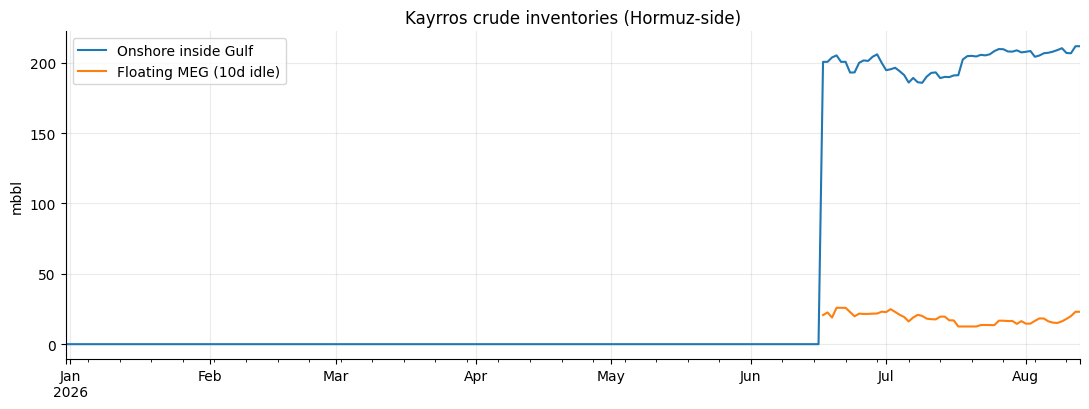

In [125]:
session = R.kayrros_session()
kay = R.pull_kayrros_bundle(cfg, start=START, end=END, session=session, refresh=REFRESH_KAYRROS)

print(f"I_inside last {float(kay['i_inside'].dropna().iloc[-1]):.2f} mbbl")
print(f"Floating last {float(kay['floating'].dropna().iloc[-1]):.2f} mbbl")
print(f"Bypass tanks last {float(kay['bypass_sum'].dropna().iloc[-1]):.2f} mbbl")

fig, ax = plt.subplots(figsize=(11, 4.2))
kay["i_inside"].plot(ax=ax, label="Onshore inside Gulf")
kay["floating"].plot(ax=ax, label="Floating MEG (10d idle)")
ax.set_ylabel("mbbl")
ax.set_title("Kayrros crude inventories (Hormuz-side)")
ax.legend()
fig.tight_layout()

## 2. Kpler crude exports and SoH exits

`kpler_inside` = country exports minus Yanbu + Fujairah + Jask (barrels that never need the strait).


c:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing\inventory_soh_residual\residual.py:446: UserWarning: Kpler flows skipped for zone 'Saudi Arabia': 'str' object has no attribute 'isoformat'
  warnings.warn(f"Kpler flows skipped for {kind} {candidate!r}: {exc}")
c:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing\inventory_soh_residual\residual.py:446: UserWarning: Kpler flows skipped for zone 'Iraq': 'str' object has no attribute 'isoformat'
  warnings.warn(f"Kpler flows skipped for {kind} {candidate!r}: {exc}")
c:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing\inventory_soh_residual\residual.py:446: UserWarning: Kpler flows skipped for zone 'United Arab Emirates': 'str' object has no attribute 'isoformat'
  warnings.warn(f"Kpler flows skipped for {kind} {candidate!r}: {exc}")
c:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing\inventory_soh_residual\residual.py:446: UserWarning: Kpler flows skipped

Kpler inside-Gulf: 0.0 mbbl   bypass: 0.0 mbbl   SoH crude: 1025.3 mbbl
Bypass split (mbbl):
red_sea    0.0
jask       0.0
adcop      0.0


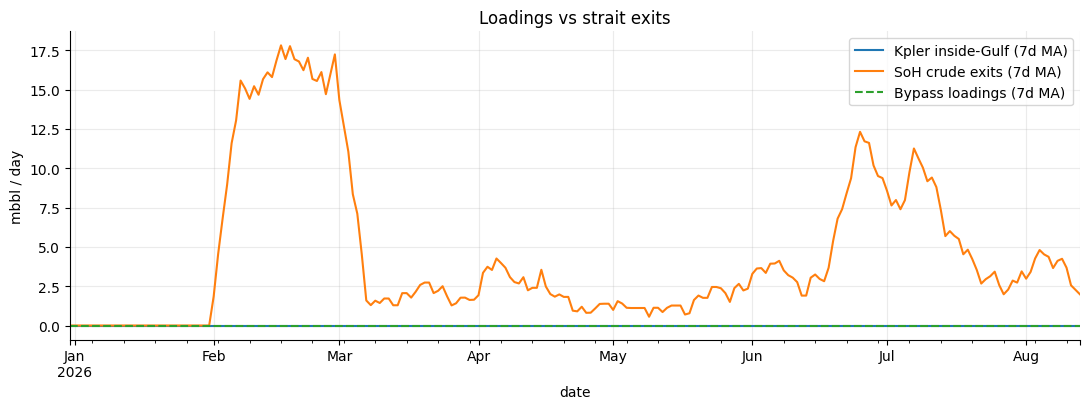

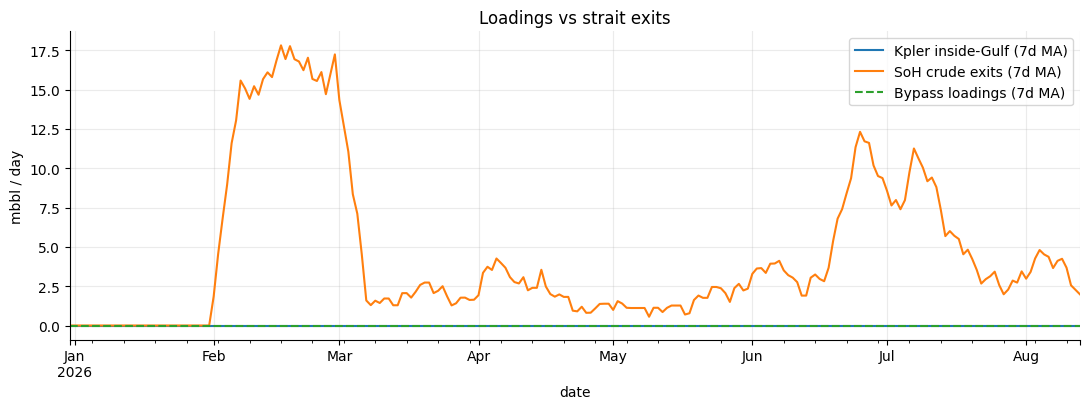

In [117]:
email, password = R.kpler_credentials(cfg)
kpler = R.pull_kpler_bundle(cfg, start=START, end=END, email=email, password=password)
soh = R.load_soh_crude_daily(cfg, start=START, end=END)

print(
    f"Kpler inside-Gulf: {kpler['kpler_inside'].sum():.1f} mbbl   "
    f"bypass: {kpler['bypass_sum'].sum():.1f} mbbl   "
    f"SoH crude: {soh['soh_crude_mbbl'].sum():.1f} mbbl"
)
bypass_totals = pd.Series({k: float(v.sum()) for k, v in kpler["bypass"].items()}, name="mbbl")
print("Bypass split (mbbl):")
print(bypass_totals.round(1).to_string())

ma = cfg["ma_days"]
fig, ax = plt.subplots(figsize=(11, 4.2))
kpler["kpler_inside"].rolling(ma, min_periods=1).mean().plot(ax=ax, label=f"Kpler inside-Gulf ({ma}d MA)")
soh["soh_crude_mbbl"].rolling(ma, min_periods=1).mean().plot(ax=ax, label=f"SoH crude exits ({ma}d MA)")
kpler["bypass_sum"].rolling(ma, min_periods=1).mean().plot(ax=ax, label=f"Bypass loadings ({ma}d MA)", ls="--")
ax.set_ylabel("mbbl / day")
ax.set_title("Loadings vs strait exits")
ax.legend()
fig.tight_layout()

ma = cfg["ma_days"]
fig, ax = plt.subplots(figsize=(11, 4.2))
kpler["kpler_inside"].rolling(ma, min_periods=1).mean().plot(ax=ax, label=f"Kpler inside-Gulf ({ma}d MA)")
soh["soh_crude_mbbl"].rolling(ma, min_periods=1).mean().plot(ax=ax, label=f"SoH crude exits ({ma}d MA)")
kpler["bypass_sum"].rolling(ma, min_periods=1).mean().plot(ax=ax, label=f"Bypass loadings ({ma}d MA)", ls="--")
ax.set_ylabel("mbbl / day")
ax.set_title("Loadings vs strait exits")
ax.legend()
fig.tight_layout()

## 3. Gulf identity `S_t`

`S_t = SoH + ΔI_inside + Δfloating + bypass`

- Stable `S` → SoH barrels match the tank system
- `S` breaks lower, tanks not building → **SoH undercount** or a production cut
- Kpler inside << `−ΔI` → **Kpler origin gap** (the sat/SPM story); SoH can still be fine


COUNT LOOKS CONSISTENT -- SoH, Kpler inside-Gulf loadings, and dI in the same band
  soh_mbbl: 1,025.348
  kpler_inside_mbbl: 0.000
  implied_offtake_mbbl: -211.670
  inventory_change_mbbl: 211.670
  soh_over_kpler: nan
  kpler_over_implied: nan
  s_recent_mbbl_d: 3.965
  s_band_mbbl_d: 3.965
  s_gap_mbbl_d: 0.000


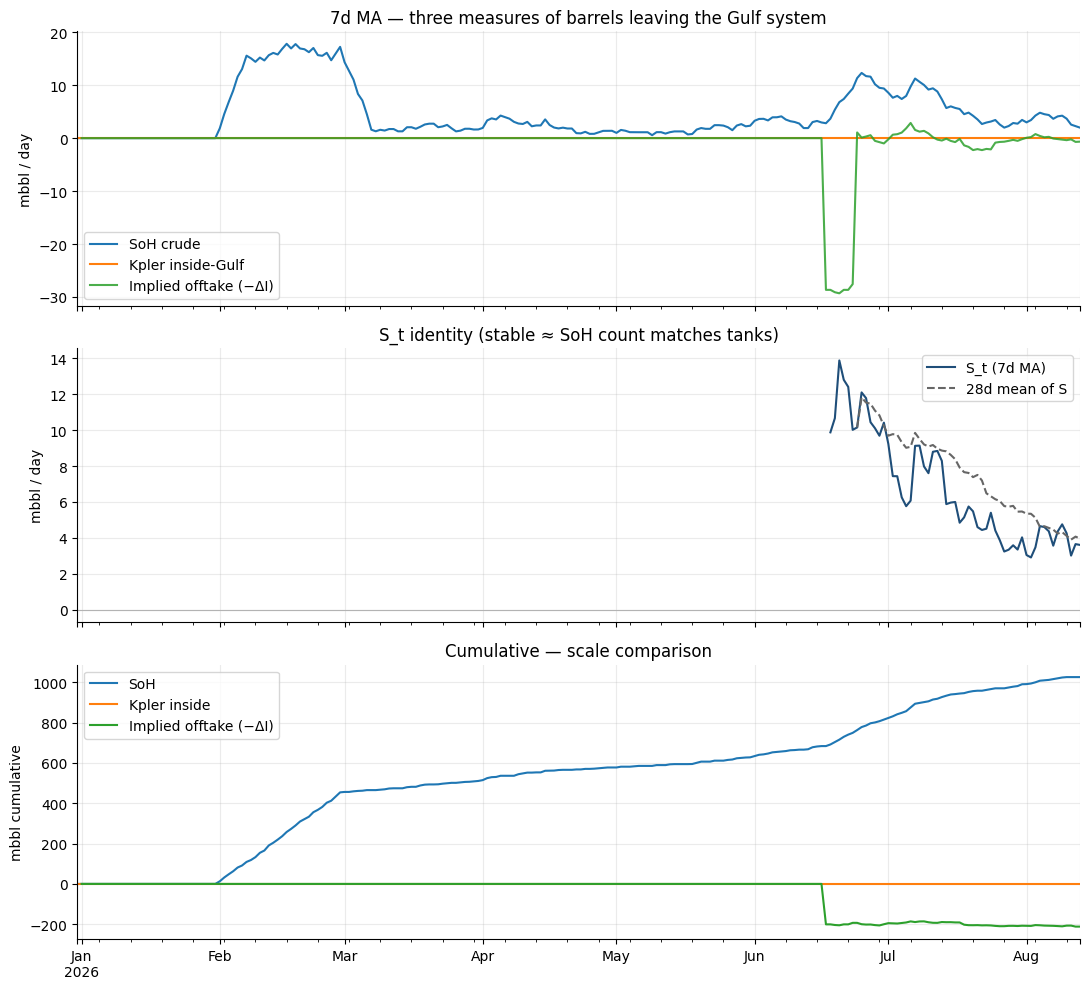

In [118]:
panel = R.build_gulf_panel(
    kay, kpler, soh,
    start=START, end=END,
    lag_days=int(cfg["soh_lag_days"]),
    ma_days=int(cfg["ma_days"]),
)
score = R.score_window(panel, band_days=int(cfg["s_band_days"]))
print(score["verdict"])
for k, v in score.items():
    if k == "verdict":
        continue
    if isinstance(v, float):
        print(f"  {k}: {v:,.3f}")

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

panel["soh_crude_mbbl_ma"].plot(ax=axes[0], label="SoH crude")
panel["kpler_inside_mbbl_ma"].plot(ax=axes[0], label="Kpler inside-Gulf")
panel["implied_offtake_ma"].plot(ax=axes[0], label="Implied offtake (−ΔI)", alpha=0.85)
axes[0].set_ylabel("mbbl / day")
axes[0].set_title(f"{cfg['ma_days']}d MA — three measures of barrels leaving the Gulf system")
axes[0].legend()

panel["s_t_ma"].plot(ax=axes[1], color="#1f4e79", label=f"S_t ({cfg['ma_days']}d MA)")
band = panel["s_t"].rolling(int(cfg["s_band_days"]), min_periods=7).mean()
band.plot(ax=axes[1], color="0.4", ls="--", label=f"{cfg['s_band_days']}d mean of S")
axes[1].axhline(0, color="0.7", lw=0.8)
axes[1].set_ylabel("mbbl / day")
axes[1].set_title("S_t identity (stable ≈ SoH count matches tanks)")
axes[1].legend()

panel[["soh_crude_mbbl", "kpler_inside_mbbl", "implied_offtake"]].cumsum().plot(ax=axes[2])
axes[2].set_ylabel("mbbl cumulative")
axes[2].set_title("Cumulative — scale comparison")
axes[2].legend(["SoH", "Kpler inside", "Implied offtake (−ΔI)"])

fig.tight_layout()

## 4. Terminal residuals

`residual = −ΔI − Kpler loadings`. Persistent positive residual at **tank_fed** sites is a Kpler undercount at origin.
Das / Zirku / Halul / Khafji are **offshore_weak** — do not treat a residual there as missing Hormuz barrels.


Cached sat occupancy rows: 51


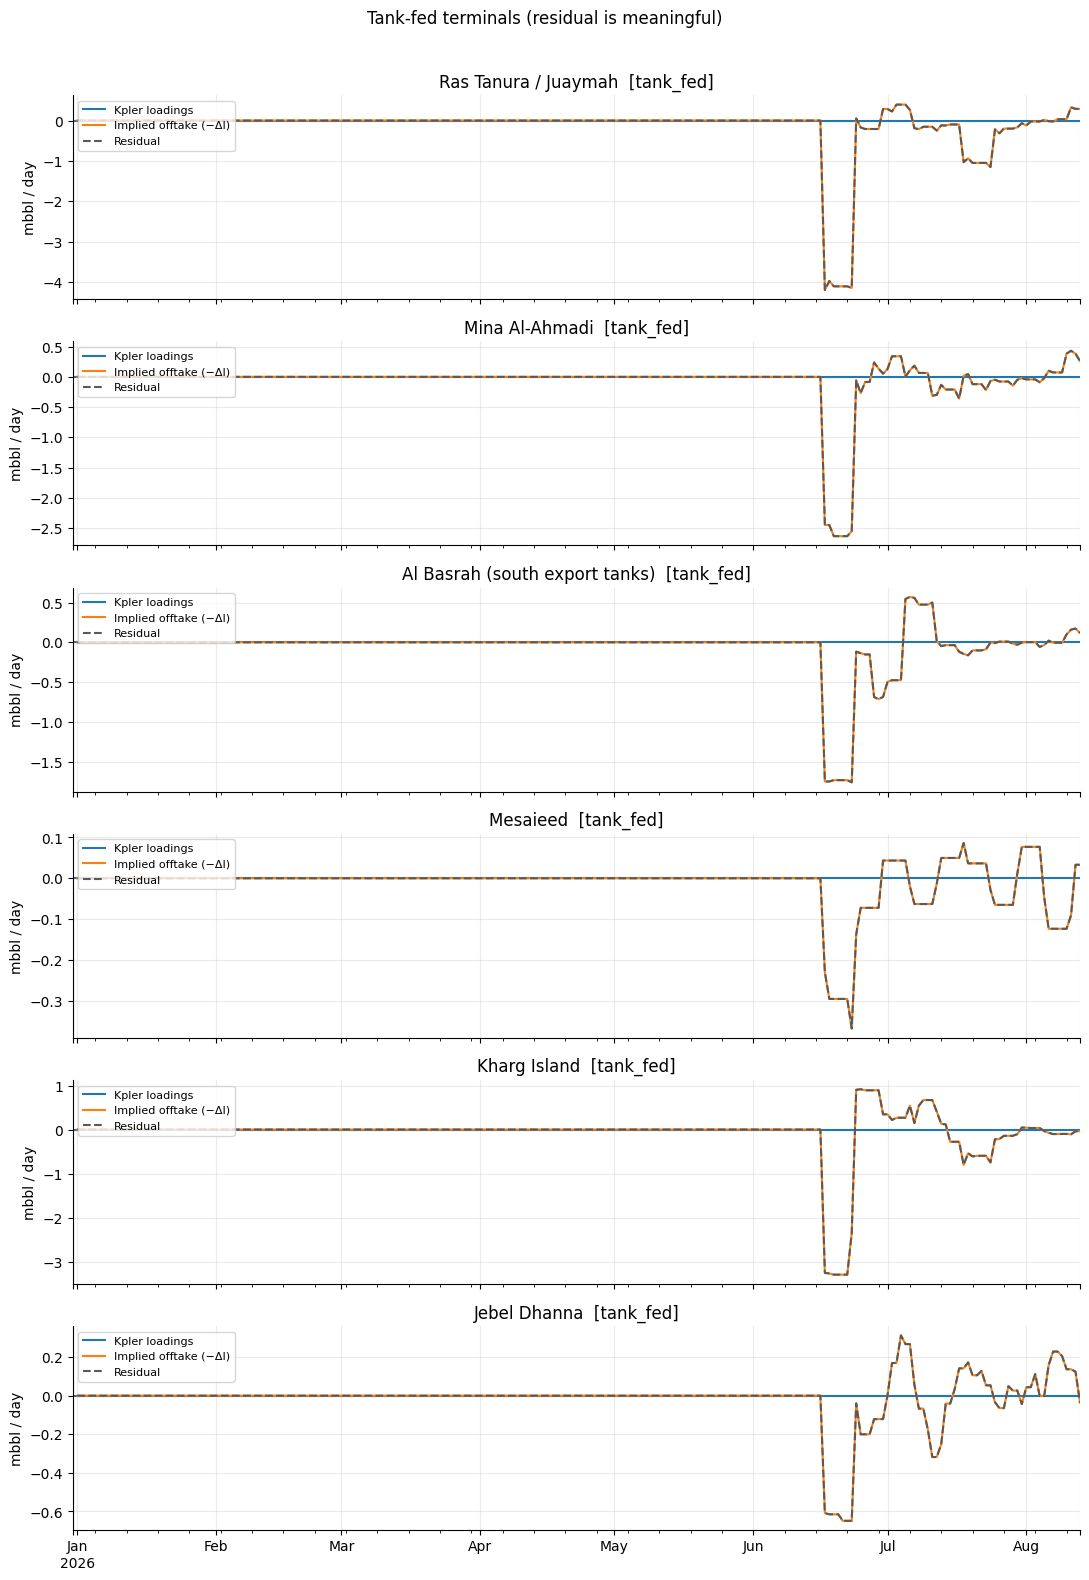

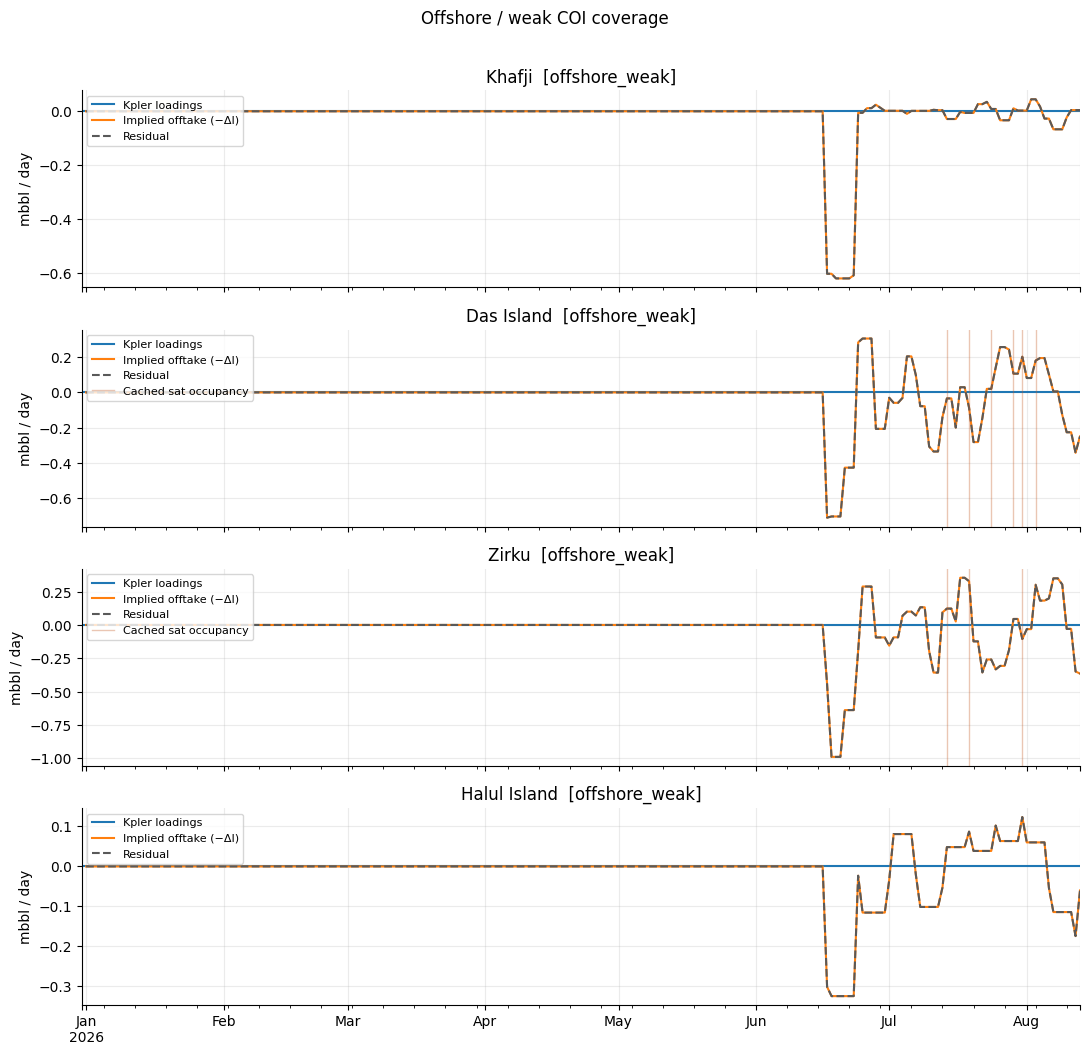

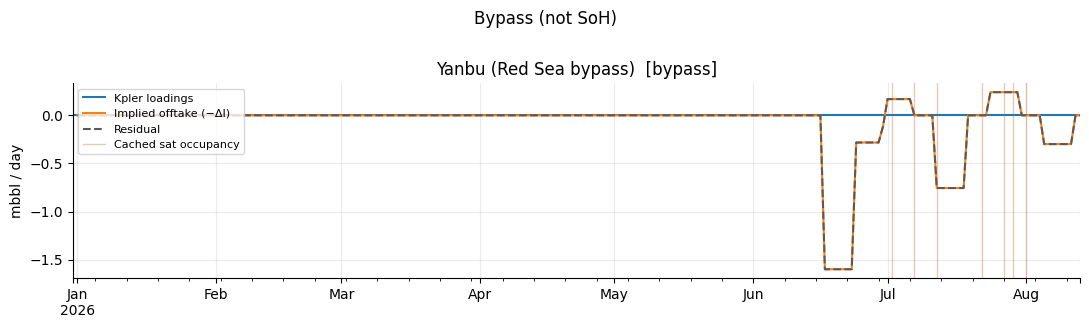

In [119]:
term_panels = R.build_terminal_panel(
    cfg, kay, kpler, start=START, end=END, ma_days=int(cfg["ma_days"])
)
sat = R.load_cached_sat(cfg)
print(f"Cached sat occupancy rows: {len(sat):,}")

roles = {"tank_fed": [], "offshore_weak": [], "bypass": [], "no_kayrros": []}
for tid, df in term_panels.items():
    roles.setdefault(df.attrs["role"], []).append(tid)

def plot_terms(ids, title):
    ids = [i for i in ids if i in term_panels]
    if not ids:
        print("none")
        return
    n = len(ids)
    fig, axes = plt.subplots(n, 1, figsize=(11, max(2.6 * n, 3.2)), sharex=True)
    if n == 1:
        axes = [axes]
    for ax, tid in zip(axes, ids):
        df = term_panels[tid]
        df["kpler_ma"].plot(ax=ax, label="Kpler loadings")
        if df["implied_ma"].notna().any():
            df["implied_ma"].plot(ax=ax, label="Implied offtake (−ΔI)")
            df["residual_ma"].plot(ax=ax, label="Residual", color="0.35", ls="--")
        hits = sat.loc[sat["terminal_id"] == tid]
        # vlines, not scatter: numpy 2 cannot promote datetime64 x with float y.
        labeled = False
        for dt in pd.to_datetime(hits["date"], errors="coerce").dropna().unique():
            ax.axvline(
                dt,
                color="#c45c26",
                alpha=0.35,
                lw=1.0,
                label="Cached sat occupancy" if not labeled else None,
            )
            labeled = True
        ax.set_title(f"{df.attrs['display_name']}  [{df.attrs['role']}]")
        ax.set_ylabel("mbbl / day")
        ax.legend(loc="upper left", fontsize=8)
    fig.suptitle(title, y=1.01)
    fig.tight_layout()

plot_terms(roles.get("tank_fed", []), "Tank-fed terminals (residual is meaningful)")
plot_terms(roles.get("offshore_weak", []), "Offshore / weak COI coverage")
plot_terms(roles.get("bypass", []), "Bypass (not SoH)")

## 5. Tank draws vs Kpler loadings

Same idea as `das_tank_inventories_daily.xlsx` → sheet **table_compare**:

1. Kayrros tank-by-tank stock changes → `total_draw` / `total_build` (kb)
2. Sum those draws between Kayrros observation dates
3. Sum Kpler crude loadings over the same windows
4. `gap_kb = |tank_draw| − kpler` — positive means tanks drew more than Kpler booked

**Charts**
1. Standalone: daily tank builds vs draws
2. Three panels: window compare, cumulative lag check, rates in **kbd** (kb / days in window)

Pass the **Kayrros shape id** directly (e.g. `zirkuIslandTerminal_adnoc` or `dasIslandTerminal_adnoc`). No config key required.


In [120]:
START

'2025-12-31'

basrah  tanks=63


tank_id,basrah2_0,basrah2_1,basrah2_2,basrah2_3,basrah2_4,basrah2_5,northRumaila_0,northRumaila_1,northRumaila_2,northRumaila_3,...,zubayr_2,zubayr_3,zubayr_4,zubayr_5,zubayr_6,zubayr_7,zubayr_8,zubayr_9,total_build,total_draw
date,,,,,,,,,,,,,,,,,,,,,
2026-07-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-07-29,56.0,-11.0,20.0,-98.0,-118.0,-5.0,0.0,0.0,0.0,0.0,...,9.0,-56.0,-10.0,-4.0,94.0,6.0,0.0,25.0,1324.0,-1068.0
2026-07-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-07-31,1.0,9.0,-25.0,11.0,67.0,3.0,0.0,0.0,0.0,0.0,...,-21.0,-48.0,6.0,3.0,-4.0,-8.0,-3.0,-29.0,211.0,-297.0
2026-08-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-08-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-08-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-08-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-08-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


table_compare (draw vs Kpler loadings, kb):


,from_date,tank_draw_kb,tank_build_kb,kpler_loadings_kb,gap_kb
date,,,,,
2026-07-31,2026-07-29,-296.8,211.0,1960.0,-1663.2
2026-08-06,2026-07-31,-436.6,159.8,10902.9,-10466.3
2026-08-10,2026-08-06,-1253.5,597.5,7827.0,-6573.5
2026-08-12,2026-08-10,-282.8,329.2,0.0,282.8


Window totals: |tank_draw|=2270 kb  Kpler=20690 kb  gap=-18420 kb


c:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\.venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


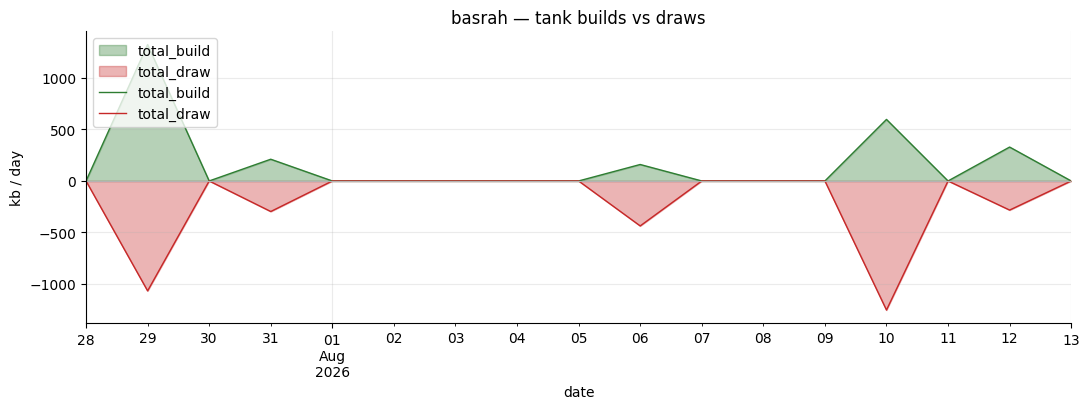

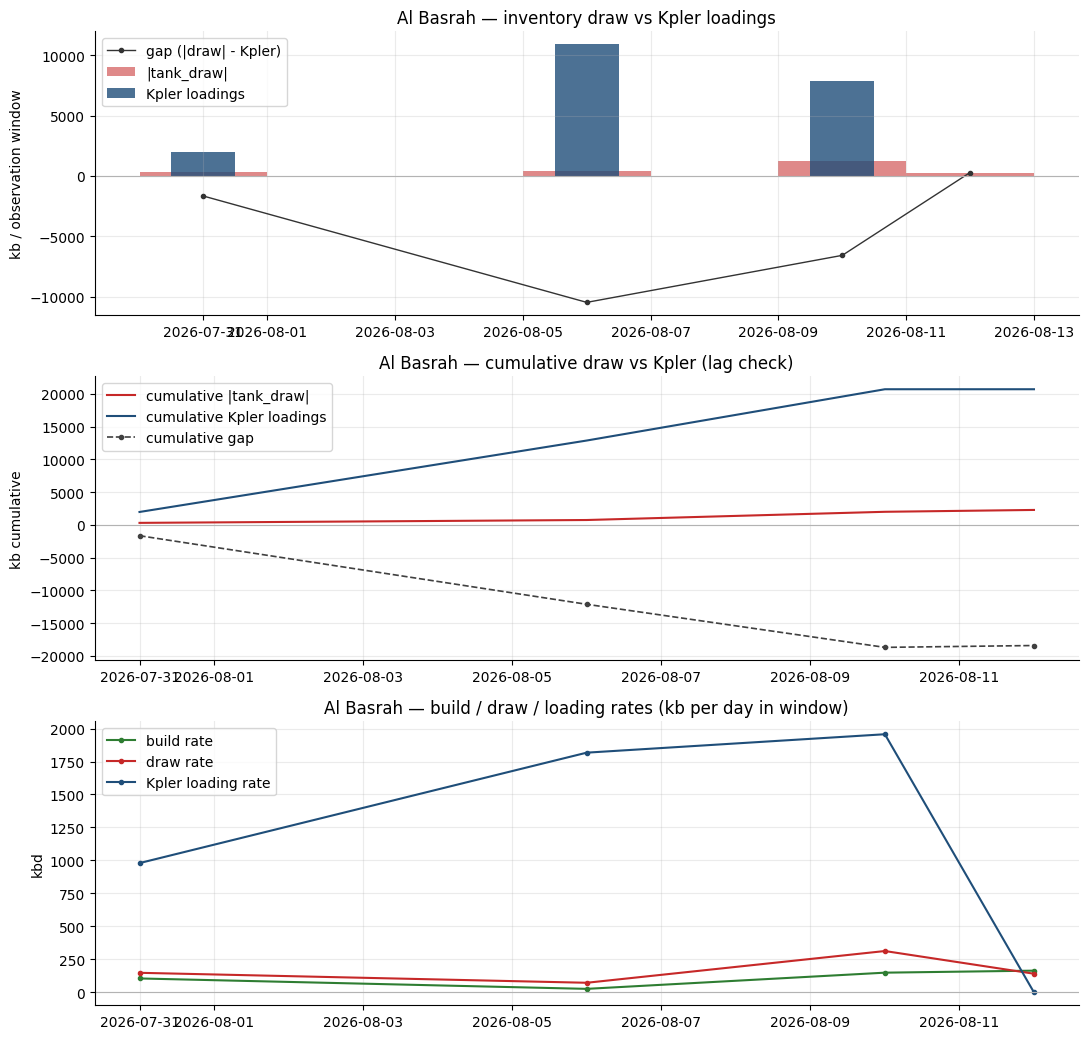

In [140]:
import importlib
import residual as R
from datetime import date 
R = importlib.reload(R)

# Kayrros shape id + matching Kpler zone/installation (edit these two).
KAYRROS_SHAPE = "basrah"   # or dasIslandTerminal_adnoc
KPLER_NAME = "Al Basrah"                          # or Das Island
KPLER_KIND = "zone"                           # zone | installation

wide, compare = R.tank_draw_vs_kpler(
    shape_id=KAYRROS_SHAPE,
    kpler_name=KPLER_NAME,
    kpler_kind=KPLER_KIND,
    start= date(2026,7,28),
    end=END,
    email=email,
    password=password,
    session=session,
    product=cfg["product"],
    refresh=True#REFRESH_KAYRROS,
)

R.OUT.mkdir(parents=True, exist_ok=True)
safe = KAYRROS_SHAPE.replace("/", "_")
wide.to_csv(R.OUT / f"tbt_{safe}_kb.csv")
compare.to_csv(R.OUT / f"tbt_{safe}_vs_kpler.csv")

print(f"{KAYRROS_SHAPE}  tanks={wide.shape[1] - 2}")
display(wide.round(0).head(10))
print("table_compare (draw vs Kpler loadings, kb):")
display(compare.round(1).tail(15))

# --- Chart 1: standalone builds vs draws ---
fig1, ax1 = plt.subplots(figsize=(11, 4.2))
ax1.fill_between(wide.index, 0, wide["total_build"], color="#2e7d32", alpha=0.35, label="total_build")
ax1.fill_between(wide.index, 0, wide["total_draw"], color="#c62828", alpha=0.35, label="total_draw")
wide["total_build"].plot(ax=ax1, color="#2e7d32", lw=1.0)
wide["total_draw"].plot(ax=ax1, color="#c62828", lw=1.0)
ax1.axhline(0, color="0.7", lw=0.8)
ax1.set_ylabel("kb / day")
ax1.set_title(f"{KAYRROS_SHAPE} — tank builds vs draws")
ax1.legend(loc="upper left")
fig1.tight_layout()

# --- Chart 2: window compare + cumulative + kbd rates ---
if not compare.empty:
    x = compare.index
    abs_draw = compare["tank_draw_kb"].abs()
    # kb -> kbd using length of each observation window
    window_days = (compare.index.to_series() - compare["from_date"]).dt.days.clip(lower=1)
    build_kbd = compare["tank_build_kb"] / window_days
    draw_kbd = abs_draw / window_days
    kpler_kbd = compare["kpler_loadings_kb"] / window_days

    fig2, axes = plt.subplots(3, 1, figsize=(11, 10.5), sharex=False)

    axes[0].bar(x, abs_draw, width=2.0, color="#c62828", alpha=0.55, label="|tank_draw|")
    axes[0].bar(x, compare["kpler_loadings_kb"], width=1.0, color="#1f4e79", alpha=0.8, label="Kpler loadings")
    axes[0].plot(x, compare["gap_kb"], color="0.2", marker="o", ms=3, lw=1.0, label="gap (|draw| - Kpler)")
    axes[0].axhline(0, color="0.7", lw=0.8)
    axes[0].set_ylabel("kb / observation window")
    axes[0].set_title(f"{KPLER_NAME} — inventory draw vs Kpler loadings")
    axes[0].legend(loc="upper left")

    cum_draw = abs_draw.cumsum()
    cum_kpler = compare["kpler_loadings_kb"].cumsum()
    cum_gap = compare["gap_kb"].cumsum()
    axes[1].plot(x, cum_draw, color="#c62828", lw=1.5, label="cumulative |tank_draw|")
    axes[1].plot(x, cum_kpler, color="#1f4e79", lw=1.5, label="cumulative Kpler loadings")
    axes[1].plot(x, cum_gap, color="0.25", lw=1.2, ls="--", marker="o", ms=3, label="cumulative gap")
    axes[1].axhline(0, color="0.7", lw=0.8)
    axes[1].set_ylabel("kb cumulative")
    axes[1].set_title(f"{KPLER_NAME} — cumulative draw vs Kpler (lag check)")
    axes[1].legend(loc="upper left")

    axes[2].plot(x, build_kbd, color="#2e7d32", lw=1.5, marker="o", ms=3, label="build rate")
    axes[2].plot(x, draw_kbd, color="#c62828", lw=1.5, marker="o", ms=3, label="draw rate")
    axes[2].plot(x, kpler_kbd, color="#1f4e79", lw=1.5, marker="o", ms=3, label="Kpler loading rate")
    axes[2].axhline(0, color="0.7", lw=0.8)
    axes[2].set_ylabel("kbd")
    axes[2].set_title(f"{KPLER_NAME} — build / draw / loading rates (kb per day in window)")
    axes[2].legend(loc="upper left")
    fig2.tight_layout()

print(
    f"Window totals: |tank_draw|={compare['tank_draw_kb'].abs().sum():.0f} kb  "
    f"Kpler={compare['kpler_loadings_kb'].sum():.0f} kb  "
    f"gap={compare['gap_kb'].sum():.0f} kb"
)


### 5a. Tank draws vs realized Port Calls (no fixtures)

Same charts as §5, but Kpler side is **Port Calls with berthing** (realized only — fixtures dropped).

Uses `KAYRROS_SHAPE` / `KPLER_NAME` / `KPLER_KIND` from the §5 cell above.

**Charts**
1. Standalone: daily tank builds vs draws
2. Three panels: window compare, cumulative lag check, rates in **kbd**


In [ ]:
# Same Kayrros tanks as §5; Kpler = realized Port Calls (no fixtures).
from loading_gaps import LocationSpec, LoadingGapConfig, fetch_port_calls

# Reuse KAYRROS_SHAPE / KPLER_NAME / KPLER_KIND from the §5 cell.
wide_pc, _ = R.tank_draw_vs_kpler(
    shape_id=KAYRROS_SHAPE,
    kpler_name=KPLER_NAME,
    kpler_kind=KPLER_KIND,
    start=START,
    end=END,
    email=email,
    password=password,
    session=session,
    product=cfg["product"],
    refresh=REFRESH_KAYRROS,
)

obs = list(wide_pc.index[(wide_pc["total_build"] + wide_pc["total_draw"].abs()) > 0.5])

gap_cfg = LoadingGapConfig(
    location=LocationSpec(name=KPLER_NAME, kind=KPLER_KIND),
    product=cfg["product"],
    start_date=START,
    end_date=END,
    with_forecast=False,
)
calls = fetch_port_calls(gap_cfg, email=email, password=password, require_berthing=True)

vol_col = "cargo_origin_barrels_split_by_product"
calls = calls.copy()
if calls.empty:
    daily_kpler = pd.Series(0.0, index=pd.date_range(START, END, freq="D"))
else:
    calls["load_date"] = pd.to_datetime(calls["start"]).dt.normalize()
    calls["kb"] = pd.to_numeric(calls[vol_col], errors="coerce").abs() / 1000.0
    daily_kpler = calls.groupby("load_date")["kb"].sum().reindex(
        pd.date_range(START, END, freq="D"), fill_value=0.0
    )

rows = []
prev = None
for dt in obs:
    if prev is None:
        prev = dt
        continue
    w = wide_pc.loc[(wide_pc.index > prev) & (wide_pc.index <= dt)]
    draw = float(w["total_draw"].sum())
    build = float(w["total_build"].sum())
    kpler = float(daily_kpler.loc[(daily_kpler.index > prev) & (daily_kpler.index <= dt)].sum())
    rows.append({
        "date": dt,
        "from_date": prev,
        "tank_draw_kb": draw,
        "tank_build_kb": build,
        "kpler_realized_kb": kpler,
        "gap_kb": abs(draw) - kpler,
    })
    prev = dt

compare_pc = pd.DataFrame(rows).set_index("date") if rows else pd.DataFrame()

print(f"{KAYRROS_SHAPE} vs PortCalls @ {KPLER_NAME} ({KPLER_KIND})")
print("PortCalls rows:", len(calls))
if not calls.empty:
    display(calls[["vessel_name", "load_date", "kb"]].sort_values("load_date").tail(15))
print("table_compare (draw vs realized PortCalls, kb):")
display(compare_pc.round(1).tail(15) if not compare_pc.empty else compare_pc)

# --- Chart 1: standalone builds vs draws ---
fig1, ax1 = plt.subplots(figsize=(11, 4.2))
ax1.fill_between(wide_pc.index, 0, wide_pc["total_build"], color="#2e7d32", alpha=0.35, label="total_build")
ax1.fill_between(wide_pc.index, 0, wide_pc["total_draw"], color="#c62828", alpha=0.35, label="total_draw")
wide_pc["total_build"].plot(ax=ax1, color="#2e7d32", lw=1.0)
wide_pc["total_draw"].plot(ax=ax1, color="#c62828", lw=1.0)
ax1.axhline(0, color="0.7", lw=0.8)
ax1.set_ylabel("kb / day")
ax1.set_title(f"{KAYRROS_SHAPE} — tank builds vs draws")
ax1.legend(loc="upper left")
fig1.tight_layout()

# --- Chart 2: window compare + cumulative + kbd rates ---
if not compare_pc.empty:
    x = compare_pc.index
    abs_draw = compare_pc["tank_draw_kb"].abs()
    window_days = (compare_pc.index.to_series() - compare_pc["from_date"]).dt.days.clip(lower=1)
    build_kbd = compare_pc["tank_build_kb"] / window_days
    draw_kbd = abs_draw / window_days
    kpler_kbd = compare_pc["kpler_realized_kb"] / window_days

    fig2, axes = plt.subplots(3, 1, figsize=(11, 10.5), sharex=False)

    axes[0].bar(x, abs_draw, width=2.0, color="#c62828", alpha=0.55, label="|tank_draw|")
    axes[0].bar(x, compare_pc["kpler_realized_kb"], width=1.0, color="#1f4e79", alpha=0.8, label="Kpler PortCalls (realized)")
    axes[0].plot(x, compare_pc["gap_kb"], color="0.2", marker="o", ms=3, lw=1.0, label="gap (|draw| - PortCalls)")
    axes[0].axhline(0, color="0.7", lw=0.8)
    axes[0].set_ylabel("kb / observation window")
    axes[0].set_title(f"{KPLER_NAME} — inventory draw vs realized PortCalls")
    axes[0].legend(loc="upper left")

    axes[1].plot(x, abs_draw.cumsum(), color="#c62828", lw=1.5, label="cumulative |tank_draw|")
    axes[1].plot(x, compare_pc["kpler_realized_kb"].cumsum(), color="#1f4e79", lw=1.5, label="cumulative PortCalls")
    axes[1].plot(x, compare_pc["gap_kb"].cumsum(), color="0.25", lw=1.2, ls="--", marker="o", ms=3, label="cumulative gap")
    axes[1].axhline(0, color="0.7", lw=0.8)
    axes[1].set_ylabel("kb cumulative")
    axes[1].set_title(f"{KPLER_NAME} — cumulative draw vs PortCalls (lag check)")
    axes[1].legend(loc="upper left")

    axes[2].plot(x, build_kbd, color="#2e7d32", lw=1.5, marker="o", ms=3, label="build rate")
    axes[2].plot(x, draw_kbd, color="#c62828", lw=1.5, marker="o", ms=3, label="draw rate")
    axes[2].plot(x, kpler_kbd, color="#1f4e79", lw=1.5, marker="o", ms=3, label="PortCalls loading rate")
    axes[2].axhline(0, color="0.7", lw=0.8)
    axes[2].set_ylabel("kbd")
    axes[2].set_title(f"{KPLER_NAME} — build / draw / PortCalls rates (kb per day in window)")
    axes[2].legend(loc="upper left")
    fig2.tight_layout()

    print(
        f"Window totals: |tank_draw|={abs_draw.sum():.0f} kb  "
        f"PortCalls={compare_pc['kpler_realized_kb'].sum():.0f} kb  "
        f"gap={compare_pc['gap_kb'].sum():.0f} kb"
    )
else:
    print("No observation windows to plot.")


## 6. Cached satellite vs Kpler occupancy

Compares **already downloaded** scenes to Kpler port-call occupancy that day.
`sat_only=1` → hull on SPM/berth in the cache, Kpler idle. That is an origin gap, not automatically a missed SoH exit.


In [ ]:
sat_gaps = pd.DataFrame()
if RUN_SAT_VS_KPLER:
    sat_gaps = R.sat_vs_kpler_occupancy(
        cfg, sat, email=email, password=password, start=START, end=END
    )
    if sat_gaps.empty:
        print("No cached occupancy rows mapped to terminals.")
    else:
        n_only = int(sat_gaps["sat_only"].sum())
        print(f"Cached sat hits: {len(sat_gaps):,}   sat-only (Kpler idle): {n_only:,}")
        display(sat_gaps.loc[sat_gaps["sat_only"] == 1].head(25))
else:
    print("Skipped sat vs Kpler occupancy.")

R.write_outputs(panel, term_panels, sat_gaps)
print("Wrote", R.OUT)